**AIM**: Implement and analyze various methods of studying correlation and regression  including Karl Pearson’s coefficient and simple linear regression.

Theory

1.What is correlation? How is it different from regression?

Correlation refers to a statistical measure that shows the strength and direction of a relationship between two variables. It tells us how variables move together, usually ranging from -1 to +1. A value close to +1 indicates a strong positive relationship, while -1 indicates a strong negative relationship. However, correlation does not imply causation. On the other hand, regression is used to model the relationship between variables and make predictions. While correlation only measures association, regression provides an equation that describes how one variable depends on another, allowing us to predict outcomes.

2. What is simple linear regression? Explain with suitable example?

Simple linear regression is a statistical method used to model the relationship between one independent variable (X) and one dependent variable (Y) by fitting a straight line. The equation is usually written as Y = a + bX, where a is the intercept and b is the slope. For example, if we want to study how hours of study affect exam scores, we can use simple linear regression to find a line that predicts marks based on study hours. If the slope is positive, it means more study hours lead to higher marks.

3.What is multicollinearity? Does it affect simple regression?

To calculate Pearson correlation in Python, we commonly use libraries like NumPy or Pandas. For example, using NumPy, we can write np.corrcoef(x, y) where x and y are two datasets. In Pandas, if the data is in a DataFrame, we can use df['x'].corr(df['y']). This function returns a value between -1 and +1, indicating the strength and direction of the linear relationship between the variables.


4.How do you calculate Pearson correlation in Python?

Multicollinearity occurs when two or more independent variables in a regression model are highly correlated with each other. This makes it difficult to determine the individual effect of each variable on the dependent variable, leading to unstable and unreliable coefficient estimates. However, in simple linear regression, there is only one independent variable, so multicollinearity does not occur and therefore does not affect simple regression.


5.A dataset shows strong correlation but poor prediction accuracy. Why?

A dataset can show strong correlation but poor prediction accuracy for several reasons. Correlation only measures the strength of a linear relationship and does not guarantee that the model fits well for prediction. There may be outliers, non-linear relationships, overfitting, or missing important variables. Additionally, high correlation does not mean the model captures all underlying patterns, so predictions may still be inaccurate despite a strong relationship between variables.

In [ ]:
import numpy as np

# Sample data
X = [1, 2, 3, 4, 5]
Y = [5, 10, 15, 20, 25]

# Manual implementation of Pearson correlation
def pearson_coefficient(x, y):
    n = len(x)
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    numerator = sum((x[i] - mean_x) * (y[i] - mean_y) for i in range(n))
    denominator = (sum((x[i] - mean_x)**2 for i in range(n)) * sum((y[i] - mean_y)**2 for i in range(n)))**0.5

    return numerator / denominator

# Calculate Karl Pearson's correlation coefficient
r = pearson_coefficient(X, Y)
print(f" Karl Pearson’s Correlation Coefficient (manual): {r:.4f}")

# Verification using scipy
from scipy.stats import pearsonr
r_scipy, _ = pearsonr(X, Y)
print(f" Verified using scipy: {r_scipy:.4f}")


 Karl Pearson’s Correlation Coefficient (manual): 1.0000
 Verified using scipy: 1.0000


Regression Equation: Marks = 5.99 * Hours + 25.67
 Mean Squared Error (MSE): 1.64
 R² Score: 0.9945


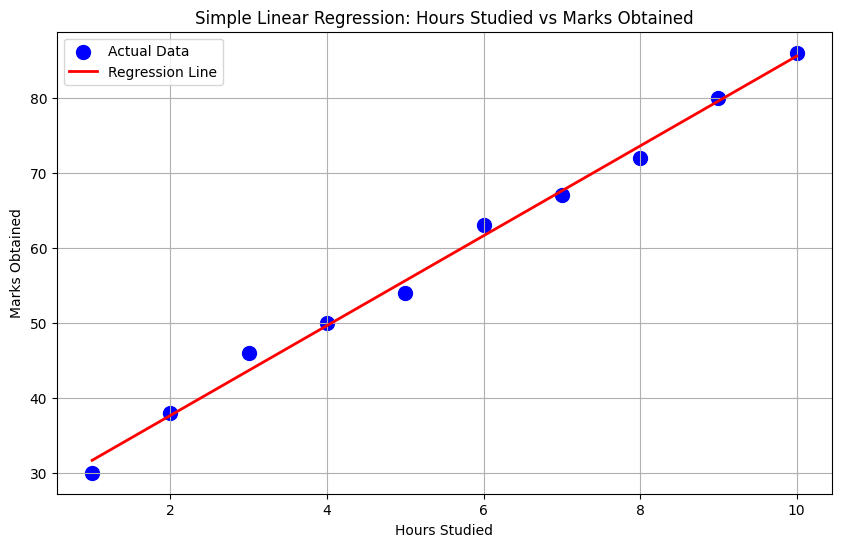

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Updated Sample Data
data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Marks_Obtained': [30, 38, 46, 50, 54, 63, 67, 72, 80, 86]
}
df = pd.DataFrame(data)

# Step 2: Split data into input (X) and output (y)
X = df[['Hours_Studied']]  # Independent variable
y = df['Marks_Obtained']   # Dependent variable

# Step 3: Train the Linear Regression Model
model = LinearRegression()
model.fit(X, y)

# Step 4: Get model parameters
slope = model.coef_[0]
intercept = model.intercept_
print(f"Regression Equation: Marks = {slope:.2f} * Hours + {intercept:.2f}")

# Step 5: Predict values
y_pred = model.predict(X)

# Step 6: Evaluate the Model
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f" Mean Squared Error (MSE): {mse:.2f}")
print(f" R² Score: {r2:.4f}")

# Step 7: Visualize the regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data', s=100)
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Hours Studied vs Marks Obtained')
plt.xlabel('Hours Studied')
plt.ylabel('Marks Obtained')
plt.grid(True)
plt.legend()
plt.show()

**Conclusion**

The simple linear regression model shows a clear positive relationship between hours studied and marks obtained. As study time increases, marks tend to improve, which is reflected in the upward-sloping regression line. The model’s equation quantifies this relationship, allowing us to predict marks based on study hours.

The evaluation metrics, such as Mean Squared Error (MSE) and R² score, indicate how well the model fits the data. A low MSE and a high R² value suggest that the model provides a good fit and can reasonably explain the variation in marks.
Overall, this analysis demonstrates that study time is a significant factor influencing academic performance, and linear regression is an effective method for modeling and predicting this relationship.